M2R Project — Shared starter module
Brownian motion, SDEs, and the path to SPDEs

Conventions (use these everywhere so our code stays consistent):
- Time grid:   numpy array of length N+1, with t[0]=0, t[N]=T
- BM paths:    shape (M, N+1), W[:, 0] = 0, M = number of Monte Carlo samples
- Randomness:  pass an `rng = np.random.default_rng(seed)` for reproducibility
- Drift / diffusion callables: f(t, x) and g(t, x), vectorised over x

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Core Utilities

In [2]:
def make_grid(T, N):
    """Uniform time grid on [0, T] with N+1 nodes."""
    return np.linspace(0.0, T, N + 1)

In [3]:
def simulate_bm(T, N, M=1, rng=None):
    """
    Simulate M independent scalar Brownian paths on [0, T] with N steps.

    Returns
    -------
    t : (N+1,) array
    W : (M, N+1) array, W[:, 0] = 0
    """
    rng = np.random.default_rng() if rng is None else rng
    t = make_grid(T, N)
    dt = T / N
    dW = rng.normal(0.0, np.sqrt(dt), size=(M, N))
    W = np.concatenate([np.zeros((M, 1)), np.cumsum(dW, axis=1)], axis=1)
    return t, W

In [4]:
def euler_maruyama(f, g, X0, T, N, M=1, rng=None, return_dW=False):
    """
    Solve  dX_t = f(t, X_t) dt + g(t, X_t) dW_t,  X_0 = X0,  by Euler-Maruyama.

    Parameters
    ----------
    f, g : callables (t: float, x: (M,) array) -> (M,) array
    X0   : scalar (broadcast) or (M,) array of initial values

    Returns
    -------
    t : (N+1,) array
    X : (M, N+1) array
    (optionally also dW : (M, N) array, the BM increments used)
    """
    rng = np.random.default_rng() if rng is None else rng
    t = make_grid(T, N)
    dt = T / N
    X = np.zeros((M, N + 1))
    X[:, 0] = X0
    dW = rng.normal(0.0, np.sqrt(dt), size=(M, N))
    for n in range(N):
        X[:, n + 1] = X[:, n] + f(t[n], X[:, n]) * dt + g(t[n], X[:, n]) * dW[:, n]
    return (t, X, dW) if return_dW else (t, X)

Standard test SDEs (where the closed form solutions are known so these can be used as benchmarks)

In [5]:
def ou(theta, mu, sigma):
    """Ornstein-Uhlenbeck: dX = theta*(mu - X) dt + sigma dW."""
    return (lambda t, x: theta * (mu - x),
            lambda t, x: sigma * np.ones_like(x))

In [6]:
def gbm(mu, sigma):
    """Geometric BM: dX = mu*X dt + sigma*X dW. Exact: X_t = X_0 exp((mu - sigma^2/2)t + sigma W_t)."""
    return (lambda t, x: mu * x,
            lambda t, x: sigma * x)

In [7]:
def gbm_exact(X0, mu, sigma, t, W):
    """Closed-form GBM path, given the same BM W used in the simulation."""
    return X0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)

How we divy up the code stuff... (decided by claude not me)

DANIEL:
  - strong_error(scheme, exact, ...)  : compare X^{dt} vs reference at T
  - weak_error(...)                   : compare E[phi(X_T)] vs E[phi(X_T^{exact})]
  - log-log plot of error vs dt, recover slopes 1/2 and 1

YUVRAJ:
  - simulate_bm_multi(d, T, N, M, ...) : d-dimensional BM, shape (M, d, N+1)
  - euler_maruyama_vec(f, G, X0, ...)  : G returns (M, d, m) matrix, dW is (M, m)
  - milstein(f, g, gprime, ...)        : add the 0.5 * g * g' * (dW^2 - dt) term

NATHAN:
  - heat_fd(u0, T, Nx, Nt)  : explicit finite-difference solver, mind CFL
  - heat_spectral(u0, T, Nt, K_modes)  : project onto sin basis, evolve coeffs
  - validation against u(t,x) = exp(-pi^2 t) sin(pi x)

These will all meet at: stochastic heat equation
du = u_xx dt + sigma dW_t   on [0,1], Dirichlet BCs
which in the sin basis becomes a decoupled system of OU SDEs
dg_n = -(n pi)^2 g_n dt + sigma dw_n,    n = 1, 2, ...
i.e. Yuvraj's vector SDE engine evolving Nathan's modes, validated by Daniel's convergence machinery.

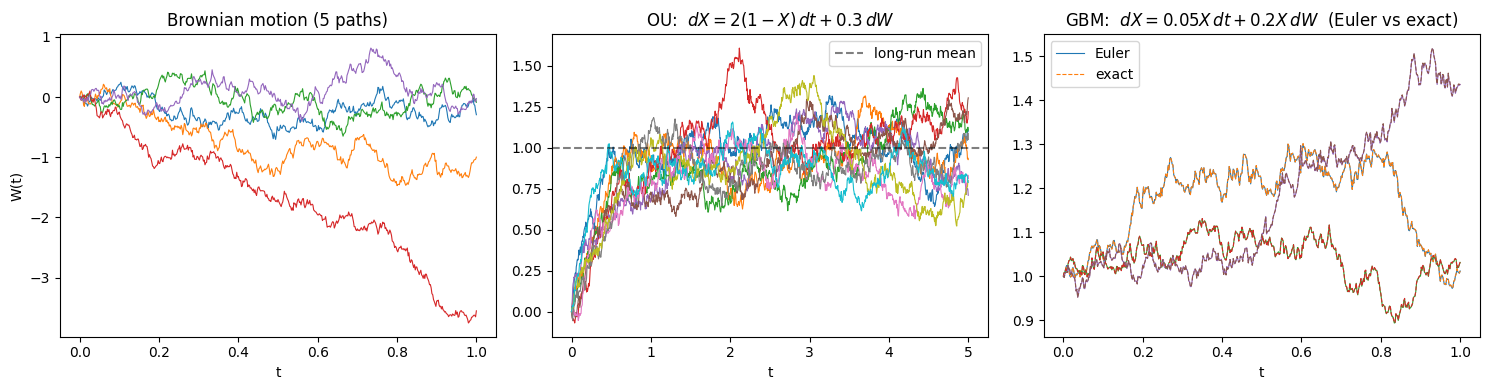

Saved figure to m2r_overview.png


In [8]:
# Main file to see everything running
rng = np.random.default_rng(42)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (1) Brownian motion
t, W = simulate_bm(T=1.0, N=500, M=5, rng=rng)
axes[0].plot(t, W.T, lw=0.8)
axes[0].set_title("Brownian motion (5 paths)")
axes[0].set_xlabel("t"); axes[0].set_ylabel("W(t)")

# (2) Ornstein-Uhlenbeck, mean-reverting to mu = 1
f, g = ou(theta=2.0, mu=1.0, sigma=0.3)
t, X = euler_maruyama(f, g, X0=0.0, T=5.0, N=1000, M=10, rng=rng)
axes[1].plot(t, X.T, lw=0.8)
axes[1].axhline(1.0, color="k", ls="--", alpha=0.5, label="long-run mean")
axes[1].set_title(r"OU:  $dX = 2(1-X)\,dt + 0.3\,dW$")
axes[1].set_xlabel("t"); axes[1].legend()

# (3) Geometric BM, with Euler vs exact on the same BM driver
f, g = gbm(mu=0.05, sigma=0.2)
t, X, dW = euler_maruyama(f, g, X0=1.0, T=1.0, N=500, M=3, rng=rng, return_dW=True)
W_path = np.concatenate([np.zeros((3, 1)), np.cumsum(dW, axis=1)], axis=1)
X_exact = gbm_exact(X0=1.0, mu=0.05, sigma=0.2, t=t, W=W_path)
for i in range(3):
    axes[2].plot(t, X[i], lw=0.8, label="Euler" if i == 0 else None)
    axes[2].plot(t, X_exact[i], lw=0.8, ls="--", label="exact" if i == 0 else None)
axes[2].set_title(r"GBM:  $dX = 0.05X\,dt + 0.2X\,dW$  (Euler vs exact)")
axes[2].set_xlabel("t"); axes[2].legend()

plt.tight_layout()
plt.savefig("m2r_overview.png", dpi=120)
plt.show()
print("Saved figure to m2r_overview.png")